# Реализация основных слоев для машинного обучения

В этом ноутбуке вы изучите и реализуете основные компоненты нейронных сетей:
- Функции активации (ReLU, Sigmoid, Tanh)
- Линейный слой (Linear)
- Последовательный контейнер (Sequential)
- Регуляризация (Dropout)
- Нормализация (BatchNorm)

Каждый блок содержит теоретическое объяснение, шаблон для реализации и тесты для проверки.


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List

# Установим seed для воспроизводимости
np.random.seed(000)


## Базовый класс для всех слоев

Сначала определим базовый класс, от которого будут наследоваться все наши слои:


In [85]:
class Layer:
    """
    Базовый класс для всех слоев нейронной сети
    """
    def __init__(self):
        self.training = True

    def forward(self, x):
        """
        Прямое распространение
        """
        raise NotImplementedError

    def backward(self, grad_output):
        """
        Обратное распространение
        """
        raise NotImplementedError

    def train(self):
        """
        Переключение в режим обучения
        """
        self.training = True

    def eval(self):
        """
        Переключение в режим инференса
        """
        self.training = False

    def __call__(self, x):
        return self.forward(x)


## 1. Функция активации ReLU

### Теория

**ReLU (Rectified Linear Unit)** - одна из самых популярных функций активации в современных нейронных сетях.

**Формула:**
- Forward: `f(x) = max(0, x)`
- Backward: `df/dx = 1 если x > 0, иначе 0`

**Преимущества:**
- Простота вычислений
- Решает проблему затухающих градиентов
- Разреженность активаций

**Недостатки:**
- "Мертвые нейроны" (dying ReLU problem)

### Реализация


In [86]:
class ReLU(Layer):
    def __init__(self):
        super().__init__()
        self.input = None

    def forward(self, x):
        """
        Прямое распространение для ReLU

        Args:
            x: входной тензор формы (batch_size, ...)

        Returns:
            выходной тензор той же формы
        """
        # TODO: Сохраните входные данные для backward pass
        self.input = x

        # TODO: Реализуйте ReLU функцию
        output = (x > 0) * x

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для ReLU

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        # TODO: Реализуйте градиент ReLU
        grad_input = (self.input > 0) * grad_output

        return grad_input


### Тестирование ReLU


In [87]:
# Тест ReLU (запустите этот код после реализации ReLU)
relu = ReLU()

# Тестовые данные
x_test = np.array([[-2, -1, 0, 1, 2]], dtype=np.float32)
expected_forward = np.array([[0, 0, 0, 1, 2]], dtype=np.float32)

# Forward pass
output = relu.forward(x_test)
print(f"Input: {x_test}")
print(f"Output: {output}")
print(f"Expected: {expected_forward}")

# Проверка forward pass
assert np.allclose(output, expected_forward), "ReLU forward pass не работает корректно!"

# Backward pass
grad_output = np.ones_like(output)
grad_input = relu.backward(grad_output)
expected_backward = np.array([[0, 0, 0, 1, 1]], dtype=np.float32)

print(f"Gradient output: {grad_output}")
print(f"Gradient input: {grad_input}")
print(f"Expected gradient: {expected_backward}")

# Проверка backward pass
assert np.allclose(grad_input, expected_backward), "ReLU backward pass не работает корректно!"

print("✅ ReLU тест пройден успешно!")

print("⚠️ Реализуйте ReLU класс выше, затем раскомментируйте этот код для тестирования")


Input: [[-2. -1.  0.  1.  2.]]
Output: [[-0. -0.  0.  1.  2.]]
Expected: [[0. 0. 0. 1. 2.]]
Gradient output: [[1. 1. 1. 1. 1.]]
Gradient input: [[0. 0. 0. 1. 1.]]
Expected gradient: [[0. 0. 0. 1. 1.]]
✅ ReLU тест пройден успешно!
⚠️ Реализуйте ReLU класс выше, затем раскомментируйте этот код для тестирования


## 2. Функция активации Sigmoid

### Теория

**Sigmoid** - классическая функция активации, которая "сжимает" входные значения в диапазон (0, 1).

**Формула:**
- Forward: `f(x) = 1 / (1 + exp(-x))`
- Backward: `df/dx = f(x) * (1 - f(x))`

**Применение:**
- Бинарная классификация (выходной слой)
- Gating механизмы (LSTM, GRU)

**Проблемы:**
- Затухающие градиенты при глубоких сетях
- Насыщение при больших значениях

### Реализация


In [88]:
class Sigmoid(Layer):
    def __init__(self):
        super().__init__()
        self.output = None

    def forward(self, x):
        """
        Прямое распространение для Sigmoid

        Args:
            x: входной тензор

        Returns:
            выходной тензор той же формы, значения в диапазоне (0, 1)
        """
        # TODO: Реализуйте sigmoid функцию
        self.output = 1.0 / (1.0 + np.exp(-x))

        return self.output

    def backward(self, grad_output):
        """
        Обратное распространение для Sigmoid

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        # TODO: Реализуйте градиент sigmoid
        grad_input = self.output * (1.0 - self.output) * grad_output

        return grad_input


### Тестирование Sigmoid


In [89]:
# Тест Sigmoid (запустите этот код после реализации Sigmoid)
print("⚠️ Реализуйте Sigmoid класс выше, затем раскомментируйте этот код для тестирования")

sigmoid = Sigmoid()

# Тестовые данные
x_test = np.array([[-10, -1, 0, 1, 10]], dtype=np.float32)

# Forward pass
output = sigmoid.forward(x_test)
print(f"Input: {x_test}")
print(f"Output: {output}")

# Проверим, что выходные значения в диапазоне (0, 1)
assert np.all(output > 0) and np.all(output < 1), "Sigmoid должен возвращать значения в диапазоне (0, 1)"

# Проверим симметричность: sigmoid(-x) = 1 - sigmoid(x)
x_sym = np.array([[1]], dtype=np.float32)
out_pos = sigmoid.forward(x_sym)
out_neg = sigmoid.forward(-x_sym)
assert np.allclose(out_neg, 1 - out_pos, atol=1e-6), "Sigmoid должен быть симметричным"

# Backward pass
grad_output = np.ones_like(output)
grad_input = sigmoid.backward(grad_output)
print(f"Gradient input: {grad_input}")

# Проверим, что градиент положительный (sigmoid монотонно возрастает)
assert np.all(grad_input >= 0), "Градиент Sigmoid должен быть неотрицательным"

print("✅ Sigmoid тест пройден успешно!")


⚠️ Реализуйте Sigmoid класс выше, затем раскомментируйте этот код для тестирования
Input: [[-10.  -1.   0.   1.  10.]]
Output: [[4.539787e-05 2.689414e-01 5.000000e-01 7.310586e-01 9.999546e-01]]
Gradient input: [[0.19661193 0.19661193 0.19661193 0.19661193 0.19661193]]
✅ Sigmoid тест пройден успешно!


## 3. Функция активации Tanh

### Теория

**Tanh (гиперболический тангенс)** - функция активации, которая "сжимает" входные значения в диапазон (-1, 1).

**Формула:**
- Forward: `f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))`
- Backward: `df/dx = 1 - f(x)²`

**Преимущества над Sigmoid:**
- Выход центрирован вокруг нуля
- Больший диапазон градиентов
- Связь с sigmoid: `tanh(x) = 2*sigmoid(2x) - 1`

### Реализация


In [90]:
class Tanh(Layer):
    def __init__(self):
        super().__init__()
        self.output = None

    def forward(self, x):
        """
        Прямое распространение для Tanh

        Args:
            x: входной тензор

        Returns:
            выходной тензор той же формы, значения в диапазоне (-1, 1)
        """
        # TODO: Реализуйте tanh функцию
        self.output = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
        # output = self.output + (self.output == -1) * 1e-7
        # output = output - (self.output == 1) * 1e-7

        return self.output

    def backward(self, grad_output):
        """
        Обратное распространение для Tanh

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        # TODO: Реализуйте градиент tanh
        grad_input = (1.0 - self.output ** 2) * grad_output

        return grad_input


### Тестирование Tanh


In [91]:
# Тест Tanh (запустите этот код после реализации Tanh)
print("⚠️ Реализуйте Tanh класс выше, затем раскомментируйте этот код для тестирования")

tanh = Tanh()

# Тестовые данные
x_test = np.array([[-10, -1, 0, 1, 10]], dtype=np.float32)

# Forward pass
output = tanh.forward(x_test)
print(f"Input: {x_test}")
print(f"Output: {output}")

# Проверим, что выходные значения в диапазоне (-1, 1)
# assert np.all(output > -1) and np.all(output < 1), "Tanh должен возвращать значения в диапазоне (-1, 1)"
# np.tanh тоже этот пункт не проходит, там мантиссы не хватает для того, чтобы быть строго больше -1 и строго меньше 1
# можно пихать костыли
# output = self.output + (self.output == -1) * 1e-7
# output = output - (self.output == 1) * 1e-7
# но зачем, если без этого все хорошо работает
assert np.all(output >= -1) and np.all(output <= 1), "Tanh должен возвращать значения в диапазоне [-1, 1]"

# Проверим антисимметричность: tanh(-x) = -tanh(x)
x_antisym = np.array([[2]], dtype=np.float32)
out_pos = tanh.forward(x_antisym)
out_neg = tanh.forward(-x_antisym)
assert np.allclose(out_neg, -out_pos, atol=1e-6), "Tanh должен быть антисимметричным"

# Проверим, что tanh(0) = 0
zero_out = tanh.forward(np.array([[0]], dtype=np.float32))
assert np.allclose(zero_out, 0, atol=1e-6), "tanh(0) должен быть равен 0"

# Backward pass
grad_output = np.ones_like(output)
grad_input = tanh.backward(grad_output)
print(f"Gradient input: {grad_input}")

# Проверим, что градиент положительный (tanh монотонно возрастает)
assert np.all(grad_input >= 0), "Градиент Tanh должен быть неотрицательным"

print("✅ Tanh тест пройден успешно!")


⚠️ Реализуйте Tanh класс выше, затем раскомментируйте этот код для тестирования
Input: [[-10.  -1.   0.   1.  10.]]
Output: [[-1.        -0.7615942  0.         0.7615942  1.       ]]
Gradient input: [[1. 1. 1. 1. 1.]]
✅ Tanh тест пройден успешно!


## 4. Линейный слой (Linear/Dense)

### Теория

**Линейный слой** - основной строительный блок нейронных сетей, выполняющий аффинное преобразование.

**Формула:**
- Forward: `y = x @ W + b`
- где W - матрица весов размера (input_size, output_size)
- b - вектор смещений размера (output_size,)

**Градиенты:**
- `∂L/∂x = grad_output @ W.T`
- `∂L/∂W = x.T @ grad_output`
- `∂L/∂b = sum(grad_output, axis=0)`

**Инициализация весов:**
- Xavier/Glorot: помогает поддерживать дисперсию активаций
- He: оптимизирована для ReLU активаций

### Реализация


In [92]:
class Linear(Layer):
    def __init__(self, input_size, output_size, bias=True):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.use_bias = bias

        # TODO: Инициализируйте веса
        self.weight = np.random.normal(
                        scale = np.sqrt(2.0 / input_size),
                        size = (input_size, output_size))

        # TODO: Инициализируйте bias (если используется)
        if self.use_bias:
            self.bias = np.random.normal(
                        scale = np.sqrt(2.0 / input_size),
                        size = (output_size,))
        else:
            self.bias = None

        # Переменные для сохранения входных данных и градиентов
        self.input = None
        self.grad_weight = None
        self.grad_bias = None

    def forward(self, x):
        """
        Прямое распространение для линейного слоя

        Args:
            x: входной тензор формы (batch_size, input_size)

        Returns:
            выходной тензор формы (batch_size, output_size)
        """
        # TODO: Сохраните входные данные для backward pass
        self.input = x

        # TODO: Реализуйте линейное преобразование
        output = x @ self.weight

        if self.use_bias:
            output = output + self.bias

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для линейного слоя

        Args:
            grad_output: градиент от следующего слоя формы (batch_size, output_size)

        Returns:
            градиент для предыдущего слоя формы (batch_size, input_size)
        """
        # TODO: Вычислите градиент по входу
        grad_input = grad_output @ self.weight.T

        # TODO: Вычислите градиент по весам
        self.grad_weight = self.input.T @ grad_output

        # TODO: Вычислите градиент по bias
        if self.use_bias:
            self.grad_bias = grad_output.sum(axis=0)

        return grad_input

    def update_weights(self, learning_rate=0.01):
        """
        Обновление весов с помощью градиентного спуска
        """
        if self.grad_weight is not None:
            self.weight -= learning_rate * self.grad_weight

        if self.use_bias and self.grad_bias is not None:
            self.bias -= learning_rate * self.grad_bias


### Тестирование Linear


In [93]:
# Тест Linear (запустите этот код после реализации Linear)
print("⚠️ Реализуйте Linear класс выше, затем раскомментируйте этот код для тестирования")

linear = Linear(input_size=3, output_size=2, bias=True)

# Проверим форму весов
assert linear.weight.shape == (3, 2), f"Неправильная форма весов: {linear.weight.shape}"
assert linear.bias.shape == (2,), f"Неправильная форма bias: {linear.bias.shape}"

print(f"Веса: \n{linear.weight}")
print(f"Bias: {linear.bias}")

# Тестовые данные
batch_size = 4
x_test = np.random.randn(batch_size, 3).astype(np.float32)

# Forward pass
output = linear.forward(x_test)
expected_shape = (batch_size, 2)

print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Expected shape: {expected_shape}")

assert output.shape == expected_shape, f"Неправильная форма выхода: {output.shape}"

# Backward pass
grad_output = np.random.randn(*output.shape).astype(np.float32)
grad_input = linear.backward(grad_output)

print(f"Gradient input shape: {grad_input.shape}")
print(f"Gradient weight shape: {linear.grad_weight.shape}")
print(f"Gradient bias shape: {linear.grad_bias.shape}")

# Проверим формы градиентов
assert grad_input.shape == x_test.shape, "Неправильная форма градиента по входу"
assert linear.grad_weight.shape == linear.weight.shape, "Неправильная форма градиента по весам"
assert linear.grad_bias.shape == linear.bias.shape, "Неправильная форма градиента по bias"

print("✅ Linear тест пройден успешно!")


⚠️ Реализуйте Linear класс выше, затем раскомментируйте этот код для тестирования
Веса: 
[[ 1.44034271  0.32672699]
 [ 0.79913622  1.82968164]
 [ 1.52485471 -0.79794405]]
Bias: [ 0.77574394 -0.12358264]
Input shape: (4, 3)
Output shape: (4, 2)
Expected shape: (4, 2)
Gradient input shape: (4, 3)
Gradient weight shape: (3, 2)
Gradient bias shape: (2,)
✅ Linear тест пройден успешно!


## 5. Последовательный контейнер (Sequential)

### Теория

**Sequential** - контейнер, который позволяет последовательно применять несколько слоев.

**Принцип работы:**
- Forward: применяет слои по порядку: `output = layer_n(...layer_2(layer_1(input))...)`
- Backward: применяет градиенты в обратном порядке

**Применение:**
- Создание простых feed-forward сетей
- Группировка слоев в блоки
- Упрощение архитектуры кода

### Реализация


In [94]:
class Sequential(Layer):
    def __init__(self, *layers):
        super().__init__()
        self.layers = list(layers)
        self.layer_outputs = []

    def add(self, layer):
        """
        Добавление слоя в последовательность
        """
        self.layers.append(layer)

    def forward(self, x):
        """
        Прямое распространение через все слои

        Args:
            x: входной тензор

        Returns:
            выходной тензор после прохождения всех слоев
        """
        # TODO: Очистите список промежуточных выходов
        self.layer_outputs.clear()

        # TODO: Последовательно примените все слои
        output = x
        for layer in self.layers:
            # TODO: Применить слой и сохранить результат
            output = layer(output)
            self.layer_outputs.append(output)

        return output

    def backward(self, grad_output):
        """
        Обратное распространение через все слои в обратном порядке

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        # TODO: Примените backward для всех слоев в обратном порядке
        grad = grad_output
        for layer in reversed(self.layers):
            # TODO: Примените backward для текущего слоя
            grad = layer.backward(grad)

        return grad

    def train(self):
        """
        Переключение всех слоев в режим обучения
        """
        super().train()
        for layer in self.layers:
            layer.train()

    def eval(self):
        """
        Переключение всех слоев в режим инференса
        """
        super().eval()
        for layer in self.layers:
            layer.eval()

    def __len__(self):
        return len(self.layers)

    def __getitem__(self, idx):
        return self.layers[idx]


# Часть 1

In [96]:
# !unzip digit-recognizer.zip # из kaggle

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from IPython.display import clear_output


train_df = pd.read_csv('train.csv')
train_labels = train_df['label'].values
train_features = train_df.drop('label', axis=1).values.astype(np.float32) / 255.0

X_train, X_val, y_train, y_val = train_test_split(train_features, train_labels,
                                                  test_size=0.2, random_state=42,
                                                  shuffle=True, stratify=train_labels)

l_train = X_train.shape[0]
l_val = X_val.shape[0]

new_perm = np.random.permutation(l_train)
new_X_train = X_train[new_perm]
new_y_train = y_train[new_perm]

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((33600, 784), (33600,), (8400, 784), (8400,))

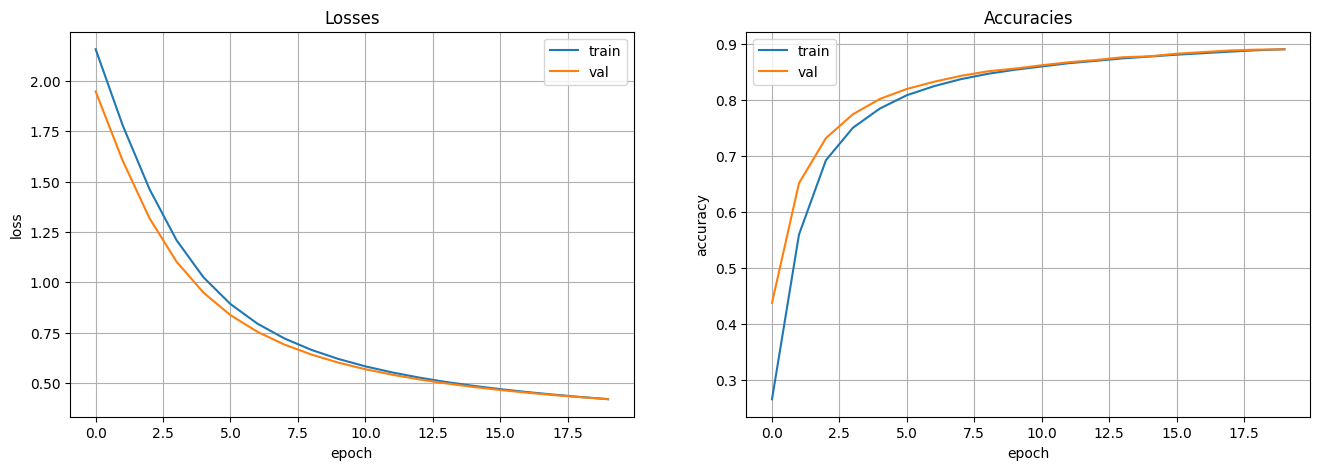

Epoch 19
train_loss 0.42035950763198393 train_accuracy 0.8899107142857143
val_loss 0.41981546494147703 val_accuracy 0.8896428571428572


In [98]:
num_epochs = 20
batch_size = 1024

model = Sequential(Linear(X_train.shape[1], 512),
                   ReLU(),
                   Linear(512, 128),
                   ReLU(),
                   Linear(128, 10))

np.random.seed(42)
trainable_layers_ids = [0, 2, 4]

def ce(pred, target):
    loss = pred - pred.max(axis=1, keepdims=True)
    loss = np.exp(loss)
    loss = loss / loss.sum(axis=1, keepdims=True)
    loss = -np.log(loss[np.arange(loss.shape[0]), target]).mean()
    return loss

def ce_grad(pred, target):
    grad = pred - pred.max(axis=1, keepdims=True)
    grad = np.exp(grad)
    grad = grad / grad.sum(axis=1, keepdims=True)
    grad = grad / pred.shape[0]
    to_sub = np.zeros_like(grad, dtype=np.float32)
    to_sub[np.arange(to_sub.shape[0]), target] = 1.0 / to_sub.shape[0]
    grad -= to_sub
    return grad


train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print("Epoch", str(epoch))

    new_perm = np.random.permutation(l_train)
    new_X_train = X_train[new_perm]
    new_y_train = y_train[new_perm]
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    for i in tqdm(range(0, l_train, batch_size), desc=f"Epoch {epoch} training"):
        data = new_X_train[i: i + batch_size, :]
        target = new_y_train[i: i + batch_size]
        # zero_grad
        for id in trainable_layers_ids:
            model[id].grad_weight = None
            model[id].grad_bias = None
        pred = model(data)
        loss = ce(pred, target)
        # backward
        grad = ce_grad(pred, target)
        grad = model.backward(grad)
        # step
        for id in trainable_layers_ids:
            model[id].update_weights(learning_rate=0.01)# * 0.5**epoch)
        train_loss += loss * data.shape[0]
        accuracy = (np.argmax(pred, axis=1) == target).mean()
        train_accuracy += accuracy * data.shape[0]
    train_loss /= l_train
    train_accuracy /= l_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss = 0.0
    val_accuracy = 0.0
    for i in tqdm(range(0, l_val, batch_size), desc=f"Epoch {epoch} validation"):
        data = X_val[i: i + batch_size, :]
        target = y_val[i: i + batch_size]
        pred = model(data)
        loss = ce(pred, target)
        val_loss += loss * data.shape[0]
        accuracy = (np.argmax(pred, axis=1) == target).mean()
        val_accuracy += accuracy * data.shape[0]
    val_loss /= l_val
    val_accuracy /= l_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    clear_output()
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(np.arange(len(train_losses)), train_losses, label='train')
    ax[0].plot(np.arange(len(val_losses)), val_losses, label='val')
    ax[0].set_xlabel('epoch')
    ax[0].set_ylabel('loss')
    ax[0].set_title('Losses')
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(np.arange(len(train_accuracies)), train_accuracies, label='train')
    ax[1].plot(np.arange(len(val_accuracies)), val_accuracies, label='val')
    ax[1].set_xlabel('epoch')
    ax[1].set_ylabel('accuracy')
    ax[1].set_title('Accuracies')
    ax[1].legend()
    ax[1].grid()

    plt.show()

    print("Epoch", str(epoch))
    print("train_loss", str(train_losses[-1]), "train_accuracy", str(train_accuracies[-1]))
    print("val_loss", str(val_losses[-1]), "val_accuracy", str(val_accuracies[-1]))


## 6. Dropout

### Теория

**Dropout** - техника регуляризации, которая случайно "выключает" некоторые нейроны во время обучения.

**Принцип работы:**
- **Обучение**: каждый нейрон сохраняется с вероятностью `(1 - dropout_rate)`
- **Инференс**: все нейроны активны, но выходы масштабируются

**Преимущества:**
- Предотвращает переобучение
- Улучшает обобщающую способность
- Эффект ансамбля моделей

### Реализация


In [99]:
class Dropout(Layer):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.mask = None

    def forward(self, x):
        """
        Прямое распространение для Dropout

        Args:
            x: входной тензор

        Returns:
            выходной тензор с примененным dropout (в режиме обучения)
        """
        if self.training:
            # TODO: Создайте бинарную маску для dropout
            self.mask = np.random.rand(*x.shape) > self.dropout_rate

            # TODO: Примените маску и масштабирование
            output = x * self.mask / (1.0 - self.dropout_rate)
        else:
            # TODO: В режиме инференса
            output = x
            self.mask = None

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для Dropout

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        if self.training:
            # TODO: Примените ту же маску к градиенту
            grad_input = grad_output * self.mask / (1.0 - self.dropout_rate)
        else:
            grad_input = grad_output

        return grad_input


### Тестирование Dropout


In [100]:
# Тест Dropout (запустите после реализации Dropout)
print("⚠️ Реализуйте Dropout класс выше, затем раскомментируйте этот код для тестирования")

dropout = Dropout(dropout_rate=0.5)

# Тестовые данные
x_test = np.ones((100, 10), dtype=np.float32)

# Тест в режиме обучения
dropout.train()
output_train = dropout.forward(x_test)

print(f"Режим обучения:")
print(f"Input mean: {x_test.mean():.3f}")
print(f"Output mean: {output_train.mean():.3f}")
print(f"Proportion of zeros: {(output_train == 0).mean():.3f}")

# Проверим, что часть нейронов "выключена"
zeros_ratio = (output_train == 0).mean()
expected_zeros = 0.5  # dropout_rate
assert abs(zeros_ratio - expected_zeros) < 0.1, f"Неправильная доля нулевых значений: {zeros_ratio}"

# Проверим масштабирование
assert abs(output_train.mean() - x_test.mean()) < 0.1, "Неправильное масштабирование в режиме обучения"

# Тест в режиме инференса
dropout.eval()
output_eval = dropout.forward(x_test)

print(f"\nРежим инференса:")
print(f"Output mean: {output_eval.mean():.3f}")
print(f"Proportion of zeros: {(output_eval == 0).mean():.3f}")

# В режиме инференса все значения должны остаться
assert np.allclose(output_eval, x_test), "В режиме инференса выход должен совпадать с входом"

# Тест backward pass
dropout.train()
output_train = dropout.forward(x_test)
grad_output = np.ones_like(output_train)
grad_input = dropout.backward(grad_output)

print(f"\nGradient test:")
print(f"Grad input shape: {grad_input.shape}")
print(f"Grad input mean: {grad_input.mean():.3f}")

assert grad_input.shape == x_test.shape, "Неправильная форма градиента"

print("✅ Dropout тест пройден успешно!")


⚠️ Реализуйте Dropout класс выше, затем раскомментируйте этот код для тестирования
Режим обучения:
Input mean: 1.000
Output mean: 0.984
Proportion of zeros: 0.508

Режим инференса:
Output mean: 1.000
Proportion of zeros: 0.000

Gradient test:
Grad input shape: (100, 10)
Grad input mean: 1.080
✅ Dropout тест пройден успешно!


## 7. Batch Normalization

### Теория

**Batch Normalization** - техника нормализации, которая стабилизирует обучение глубоких сетей.

**Принцип работы:**
1. Нормализация: `(x - mean) / sqrt(var + eps)`
2. Масштабирование и сдвиг: `gamma * normalized + beta`

**Преимущества:**
- Ускоряет обучение
- Позволяет использовать большие learning rate
- Уменьшает зависимость от инициализации
- Эффект регуляризации

**Различия между режимами:**
- **Обучение**: используется статистика текущего batch
- **Инференс**: используется накопленная статистика

### Реализация


In [101]:
class BatchNorm(Layer):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        # TODO: Инициализируйте обучаемые параметры gamma и beta
        self.gamma = np.ones((self.num_features, ), dtype=np.float32)
        self.beta = np.zeros((self.num_features, ), dtype=np.float32)

        # TODO: Инициализируйте накопленную статистику
        self.running_mean = np.zeros((self.num_features, ), dtype=np.float32)
        self.running_var = np.ones((self.num_features, ), dtype=np.float32)

        # Переменные для backward pass
        self.batch_mean = None
        self.batch_var = None
        self.normalized = None
        self.input = None
        self.grad_gamma = None
        self.grad_beta = None

    def forward(self, x):
        """
        Прямое распространение для Batch Normalization

        Args:
            x: входной тензор формы (batch_size, num_features)

        Returns:
            нормализованный выходной тензор той же формы
        """
        self.input = x

        if self.training:
            # TODO: Вычислите статистику текущего batch
            self.batch_mean = x.mean(axis=0)
            self.batch_var = x.var(axis=0)

            # TODO: Обновите накопленную статистику
            self.running_mean = self.running_mean * (1.0 - self.momentum) + \
                                self.batch_mean * self.momentum
            self.running_var = self.running_var * (1.0 - self.momentum) + \
                                self.batch_var * self.momentum

            mean = self.batch_mean
            var = self.batch_var
        else:
            # TODO: Используйте накопленную статистику
            mean = self.running_mean
            var = self.running_var

        # TODO: Нормализация
        self.normalized = (x - mean) / np.sqrt(var + self.eps)

        # TODO: Масштабирование и сдвиг
        output = self.normalized * self.gamma + self.beta

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для Batch Normalization
        """
        # TODO: Вычислите градиенты по параметрам
        self.grad_gamma = (grad_output * self.normalized).sum(axis=0)
        self.grad_beta = grad_output.sum(axis=0)

        # TODO: Вычислите градиент по входу
        x = self.input
        y1 = self.batch_mean
        y2 = self.batch_var
        y3 = np.sqrt(y2 + self.eps)
        y4 = x - y1
        y5 = self.normalized
        dy5 = self.gamma * grad_output
        dy4 = dy5 * 1.0 / y3
        dy3 = (dy5 * y4 * (-1.0) / (y2 + self.eps)).sum(axis=0)
        dy2 = dy3 * 0.5 / y3
        dy1 = dy2 * 1.0 / x.shape[0] * ((x - y1) * (-2.0)).sum(axis=0) + \
              (dy4 * (-1.0)).sum(axis=0)
        dx = np.repeat(dy1.reshape(1, -1), x.shape[0], axis=0) / x.shape[0] + \
              np.repeat(dy2.reshape(1, -1), x.shape[0], axis=0) / x.shape[0] * 2.0 * (x - y1) + \
              dy4

        grad_input = dx

        return grad_input

    def update_weights(self, learning_rate=0.01):
        """
        Обновление параметров
        """
        if self.grad_gamma is not None:
            self.gamma -= learning_rate * self.grad_gamma

        if self.grad_beta is not None:
            self.beta -= learning_rate * self.grad_beta


In [102]:
# Тест BatchNorm (запустите после реализации BatchNorm)
print("⚠️ Реализуйте BatchNorm класс выше, затем раскомментируйте этот код для тестирования")

batch_norm = BatchNorm(num_features=4)

# Проверим инициализацию
assert np.allclose(batch_norm.gamma, 1.0), "Gamma должно инициализироваться единицами"
assert np.allclose(batch_norm.beta, 0.0), "Beta должно инициализироваться нулями"
assert np.allclose(batch_norm.running_mean, 0.0), "Running mean должно инициализироваться нулями"
assert np.allclose(batch_norm.running_var, 1.0), "Running var должно инициализироваться единицами"

print(f"Gamma: {batch_norm.gamma}")
print(f"Beta: {batch_norm.beta}")

# Тестовые данные с известной статистикой
x_test = np.array([
    [1, 2, 3, 4],
    [2, 3, 4, 5],
    [3, 4, 5, 6]
], dtype=np.float32)

print(f"Input: \n{x_test}")
print(f"Input mean per feature: {x_test.mean(axis=0)}")
print(f"Input std per feature: {x_test.std(axis=0)}")

# Forward pass в режиме обучения
batch_norm.train()
output = batch_norm.forward(x_test)

print(f"\nOutput: \n{output}")
print(f"Output mean per feature: {output.mean(axis=0)}")
print(f"Output std per feature: {output.std(axis=0)}")

# Проверим, что выход нормализован (среднее ≈ 0, std ≈ 1)
assert np.allclose(output.mean(axis=0), 0, atol=1e-6), "Среднее должно быть близко к 0"
assert np.allclose(output.std(axis=0), 1, atol=1e-6), "Стандартное отклонение должно быть близко к 1"

# Проверим обновление running статистики
print(f"\nRunning mean: {batch_norm.running_mean}")
print(f"Running var: {batch_norm.running_var}")

# Backward pass
grad_output = np.ones_like(output)
grad_input = batch_norm.backward(grad_output)

print(f"\nGradient input shape: {grad_input.shape}")
print(f"Gradient gamma shape: {batch_norm.grad_gamma.shape}")
print(f"Gradient beta shape: {batch_norm.grad_beta.shape}")

assert grad_input.shape == x_test.shape, "Неправильная форма градиента по входу"
assert batch_norm.grad_gamma.shape == batch_norm.gamma.shape, "Неправильная форма градиента gamma"
assert batch_norm.grad_beta.shape == batch_norm.beta.shape, "Неправильная форма градиента beta"

# Тест режима инференса
batch_norm.eval()
output_eval = batch_norm.forward(x_test)
print(f"\nInference mode output mean: {output_eval.mean(axis=0)}")

print("✅ BatchNorm тест пройден успешно!")


⚠️ Реализуйте BatchNorm класс выше, затем раскомментируйте этот код для тестирования
Gamma: [1. 1. 1. 1.]
Beta: [0. 0. 0. 0.]
Input: 
[[1. 2. 3. 4.]
 [2. 3. 4. 5.]
 [3. 4. 5. 6.]]
Input mean per feature: [2. 3. 4. 5.]
Input std per feature: [0.8164966 0.8164966 0.8164966 0.8164966]

Output: 
[[-1.2247356 -1.2247356 -1.2247356 -1.2247356]
 [ 0.         0.         0.         0.       ]
 [ 1.2247356  1.2247356  1.2247356  1.2247356]]
Output mean per feature: [0. 0. 0. 0.]
Output std per feature: [0.99999243 0.99999243 0.99999243 0.99999243]

Running mean: [0.2 0.3 0.4 0.5]
Running var: [0.96666664 0.96666664 0.96666664 0.96666664]

Gradient input shape: (3, 4)
Gradient gamma shape: (4,)
Gradient beta shape: (4,)

Inference mode output mean: [1.8307619 2.746143  3.6615238 4.5769053]
✅ BatchNorm тест пройден успешно!


## 8. Adam Оптимизатор

### Теория

**Adam (Adaptive Moment Estimation)** - современный оптимизатор, сочетающий преимущества RMSprop и Momentum.

**Принцип работы:**
1. Вычисление экспоненциального скользящего среднего градиентов (momentum)
2. Вычисление экспоненциального скользящего среднего квадратов градиентов (RMSprop)
3. Коррекция смещения (bias correction)
4. Обновление параметров

**Преимущества:**
- Адаптивные learning rate для каждого параметра
- Хорошо работает на практике
- Требует мало настройки гиперпараметров

### Реализация


In [103]:
class Adam:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # Словари для хранения моментов для каждого слоя
        self.m = {}  # first moment
        self.v = {}  # second moment
        self.t = 0   # time step

    def update(self, layers, layers_ids):
        """
        Обновление параметров слоя с помощью Adam

        Args:
            layer: слой с градиентами
            layer_id: уникальный идентификатор слоя
        """
        self.t += 1

        if not isinstance(layers, list):
            layers = [layers]
            layers_ids = [layers_ids]

        for layer, layer_id in zip(layers, layers_ids):
            # TODO: Обновите веса, если есть градиенты
            if hasattr(layer, 'grad_weight') and layer.grad_weight is not None:
                # TODO: Инициализируйте моменты для весов
                if f"{layer_id}_weight" not in self.m:
                    self.m[f"{layer_id}_weight"] = np.zeros_like(layer.grad_weight, dtype=np.float32)
                    self.v[f"{layer_id}_weight"] = np.zeros_like(layer.grad_weight, dtype=np.float32)

                # TODO: Обновите первый момент (momentum)
                self.m[f"{layer_id}_weight"] = self.beta1 * self.m[f"{layer_id}_weight"] + \
                                                (1 - self.beta1) * layer.grad_weight

                # TODO: Обновите второй момент (RMSprop)
                self.v[f"{layer_id}_weight"] = self.beta2 * self.v[f"{layer_id}_weight"] + \
                                                (1 - self.beta2) * layer.grad_weight**2

                # TODO: Коррекция смещения
                m_corrected = self.m[f"{layer_id}_weight"] / (1 - self.beta1 ** self.t)
                v_corrected = self.v[f"{layer_id}_weight"] / (1 - self.beta2 ** self.t)

                # TODO: Обновите веса
                layer.weight = layer.weight - self.learning_rate * m_corrected / (np.sqrt(v_corrected) + self.eps)

            # TODO: Обновите bias аналогично весам
            if hasattr(layer, 'grad_bias') and layer.grad_bias is not None:
                if f"{layer_id}_bias" not in self.m:
                    self.m[f"{layer_id}_bias"] = np.zeros_like(layer.grad_bias, dtype=np.float32)
                    self.v[f"{layer_id}_bias"] = np.zeros_like(layer.grad_bias, dtype=np.float32)

                # TODO: Реализуйте обновление bias
                # TODO: Обновите первый момент (momentum)
                self.m[f"{layer_id}_bias"] = self.beta1 * self.m[f"{layer_id}_bias"] + \
                                                (1 - self.beta1) * layer.grad_bias

                # TODO: Обновите второй момент (RMSprop)
                self.v[f"{layer_id}_bias"] = self.beta2 * self.v[f"{layer_id}_bias"] + \
                                                (1 - self.beta2) * layer.grad_bias**2

                # TODO: Коррекция смещения
                m_corrected = self.m[f"{layer_id}_bias"] / (1 - self.beta1 ** self.t)
                v_corrected = self.v[f"{layer_id}_bias"] / (1 - self.beta2 ** self.t)

                # TODO: Обновите веса
                layer.bias = layer.bias - self.learning_rate * m_corrected / (np.sqrt(v_corrected) + self.eps)


            if hasattr(layer, 'grad_gamma') and layer.grad_gamma is not None:
                if f"{layer_id}_gamma" not in self.m:
                    self.m[f"{layer_id}_gamma"] = np.zeros_like(layer.grad_gamma, dtype=np.float32)
                    self.v[f"{layer_id}_gamma"] = np.zeros_like(layer.grad_gamma, dtype=np.float32)
                self.m[f"{layer_id}_gamma"] = self.beta1 * self.m[f"{layer_id}_gamma"] + \
                                                (1 - self.beta1) * layer.grad_gamma
                self.v[f"{layer_id}_gamma"] = self.beta2 * self.v[f"{layer_id}_gamma"] + \
                                                (1 - self.beta2) * layer.grad_gamma**2
                m_corrected = self.m[f"{layer_id}_gamma"] / (1 - self.beta1 ** self.t)
                v_corrected = self.v[f"{layer_id}_gamma"] / (1 - self.beta2 ** self.t)
                layer.gamma = layer.gamma - self.learning_rate * m_corrected / (np.sqrt(v_corrected) + self.eps)
            if hasattr(layer, 'grad_beta') and layer.grad_beta is not None:
                if f"{layer_id}_beta" not in self.m:
                    self.m[f"{layer_id}_beta"] = np.zeros_like(layer.grad_beta, dtype=np.float32)
                    self.v[f"{layer_id}_beta"] = np.zeros_like(layer.grad_beta, dtype=np.float32)
                self.m[f"{layer_id}_beta"] = self.beta1 * self.m[f"{layer_id}_beta"] + \
                                                (1 - self.beta1) * layer.grad_beta
                self.v[f"{layer_id}_beta"] = self.beta2 * self.v[f"{layer_id}_beta"] + \
                                                (1 - self.beta2) * layer.grad_beta**2
                m_corrected = self.m[f"{layer_id}_beta"] / (1 - self.beta1 ** self.t)
                v_corrected = self.v[f"{layer_id}_beta"] / (1 - self.beta2 ** self.t)
                layer.beta = layer.beta - self.learning_rate * m_corrected / (np.sqrt(v_corrected) + self.eps)



    def zero_grad(self, layers):
        """
        Обнуление градиентов
        """
        for layer in layers:
            if hasattr(layer, 'grad_weight'):
                layer.grad_weight = None
            if hasattr(layer, 'grad_bias'):
                layer.grad_bias = None
            if hasattr(layer, 'grad_gamma'):
                layer.grad_gamma = None
            if hasattr(layer, 'grad_beta'):
                layer.grad_beta = None


In [104]:
# Тест Adam (запустите после реализации Adam)
print("⚠️ Реализуйте Adam класс выше, затем раскомментируйте этот код для тестирования")

# Создание тестового слоя
layer = Linear(3, 2)
adam = Adam(learning_rate=0.01)

# Создание фиктивных градиентов
layer.grad_weight = np.array([[0.1, 0.2], [0.3, 0.4], [0.5, 0.6]], dtype=np.float32)
layer.grad_bias = np.array([0.1, 0.2], dtype=np.float32)

# Сохранение начальных весов
initial_weight = layer.weight.copy()
initial_bias = layer.bias.copy()

print(f"Initial weight: \n{initial_weight}")
print(f"Initial bias: {initial_bias}")
print(f"Weight gradient: \n{layer.grad_weight}")
print(f"Bias gradient: {layer.grad_bias}")

# Проверим инициализацию Adam
assert len(adam.m) == 0, "Моменты должны быть пустыми при инициализации"
assert len(adam.v) == 0, "Моменты должны быть пустыми при инициализации"
assert adam.t == 0, "Time step должен быть равен 0"

# Выполним один шаг оптимизации
adam.update(layer, "test_layer")

print(f"\nAfter 1 step:")
print(f"Updated weight: \n{layer.weight}")
print(f"Updated bias: {layer.bias}")
print(f"Time step: {adam.t}")

# Проверим, что веса изменились
assert not np.allclose(layer.weight, initial_weight), "Веса должны измениться после обновления"
assert not np.allclose(layer.bias, initial_bias), "Bias должен измениться после обновления"

# Проверим, что моменты инициализированы
assert "test_layer_weight" in adam.m, "Момент для весов должен быть создан"
assert "test_layer_bias" in adam.m, "Момент для bias должен быть создан"
assert "test_layer_weight" in adam.v, "Момент для весов должен быть создан"
assert "test_layer_bias" in adam.v, "Момент для bias должен быть создан"

# Проверим формы моментов
assert adam.m["test_layer_weight"].shape == layer.weight.shape, "Неправильная форма момента весов"
assert adam.m["test_layer_bias"].shape == layer.bias.shape, "Неправильная форма момента bias"

# Тест zero_grad
adam.zero_grad([layer])
assert layer.grad_weight is None, "Градиенты весов должны быть обнулены"
assert layer.grad_bias is None, "Градиенты bias должны быть обнулены"

print("✅ Adam тест пройден успешно!")


⚠️ Реализуйте Adam класс выше, затем раскомментируйте этот код для тестирования
Initial weight: 
[[-4.80406439e-02  1.41015954e+00]
 [ 1.32094030e+00  1.59626560e-04]
 [ 4.57806316e-01  1.35088954e-01]]
Initial bias: [-0.42919006 -0.12052033]
Weight gradient: 
[[0.1 0.2]
 [0.3 0.4]
 [0.5 0.6]]
Bias gradient: [0.1 0.2]

After 1 step:
Updated weight: 
[[-0.05804064  1.40015954]
 [ 1.3109403  -0.00984037]
 [ 0.44780632  0.12508895]]
Updated bias: [-0.43919006 -0.13052033]
Time step: 1
✅ Adam тест пройден успешно!


## 9. Функции потерь

### Теория

**Функции потерь** измеряют разность между предсказаниями модели и истинными значениями.

**Cross-Entropy Loss:**
- Используется для задач классификации
- Формула: `-log(p_correct_class)`
- Штрафует неверные предсказания экспоненциально

**Mean Squared Error (MSE):**
- Используется для задач регрессии
- Формула: `(y_pred - y_true)²`
- Чувствителен к выбросам

### Реализация


In [105]:
class CrossEntropyLoss:
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """
        Вычисление Cross-Entropy Loss

        Args:
            predictions: предсказания модели (batch_size, num_classes)
            targets: истинные метки класса (batch_size,)

        Returns:
            значение функции потерь
        """
        self.predictions = predictions
        self.targets = targets

        # TODO: Примените softmax к предсказаниям
        self.softmax_pred = softmax(predictions)
        softmax_pred = self.softmax_pred

        # TODO: Вычислите cross-entropy loss
        self.ohe = one_hot_encode(targets, predictions.shape[1])
        loss = -np.log((softmax_pred * self.ohe).sum(axis=1)).mean()

        return loss

    def backward(self):
        """
        Вычисление градиента Cross-Entropy Loss

        Returns:
            градиент по предсказаниям
        """
        # TODO: Вычислите градиент
        grad = self.softmax_pred / self.softmax_pred.shape[0]
        grad -= self.ohe / self.ohe.shape[0]

        return grad

    def __call__(self, predictions, targets):
        return self.forward(predictions, targets)


class MSELoss:
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """
        Вычисление Mean Squared Error

        Args:
            predictions: предсказания модели
            targets: истинные значения

        Returns:
            значение функции потерь
        """
        self.predictions = predictions
        self.targets = targets

        # TODO: Вычислите MSE
        loss = ((predictions - targets) ** 2).mean()

        return loss

    def backward(self):
        """
        Вычисление градиента MSE

        Returns:
            градиент по предсказаниям
        """
        # TODO: Вычислите градиент MSE
        grad = 2.0 / self.predictions.size * (self.predictions - self.targets)

        return grad

    def __call__(self, predictions, targets):
        return self.forward(predictions, targets)


def softmax(x):
    """
    Устойчивая реализация softmax
    """
    # TODO: Реализуйте softmax функцию
    output = x - x.max(axis=1, keepdims=True)
    output = np.exp(output)
    output = output / output.sum(axis=1, keepdims=True)
    return output


def one_hot_encode(labels, num_classes):
    """
    Преобразование меток в one-hot кодировку
    """
    # TODO: Создайте one-hot кодировку
    ohe = np.zeros((labels.shape[0], num_classes))
    ohe[np.arange(labels.shape[0]), labels] = 1
    return ohe


In [106]:
# Тест функций потерь (запустите после реализации Loss функций)
print("⚠️ Реализуйте функции потерь выше, затем раскомментируйте этот код для тестирования")

# Тест CrossEntropyLoss
print("🔥 Тестирование CrossEntropyLoss...")
ce_loss = CrossEntropyLoss()

# Тестовые данные
predictions = np.array([[2.0, 1.0, 0.1], [1.0, 3.0, 0.2]], dtype=np.float32)
targets = np.array([0, 1], dtype=np.int32)

print(f"Predictions: \n{predictions}")
print(f"Targets: {targets}")

# Forward pass
loss_value = ce_loss.forward(predictions, targets)
print(f"CrossEntropy Loss: {loss_value:.4f}")

# Проверим, что loss положительный
assert loss_value > 0, "CrossEntropy loss должен быть положительным"

# Backward pass
grad = ce_loss.backward()
print(f"Gradient shape: {grad.shape}")
print(f"Gradient: \n{grad}")

# Проверим форму градиента
assert grad.shape == predictions.shape, "Неправильная форма градиента CrossEntropy"

# Проверим, что сумма градиентов по классам равна 0 (свойство softmax)
assert np.allclose(grad.sum(axis=1), 0, atol=1e-6), "Сумма градиентов по классам должна быть 0"

print("✅ CrossEntropyLoss тест пройден!")

# Тест MSELoss
print("\n📊 Тестирование MSELoss...")
mse_loss = MSELoss()

# Тестовые данные для регрессии
predictions_reg = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)
targets_reg = np.array([[1.5, 2.5], [2.5, 3.5]], dtype=np.float32)

print(f"Predictions: \n{predictions_reg}")
print(f"Targets: \n{targets_reg}")

# Forward pass
mse_value = mse_loss.forward(predictions_reg, targets_reg)
print(f"MSE Loss: {mse_value:.4f}")

# Проверим, что loss положительный
assert mse_value >= 0, "MSE loss должен быть неотрицательным"

# Backward pass
grad_mse = mse_loss.backward()
print(f"MSE Gradient shape: {grad_mse.shape}")
print(f"MSE Gradient: \n{grad_mse}")

# Проверим форму градиента
assert grad_mse.shape == predictions_reg.shape, "Неправильная форма градиента MSE"

print("✅ MSELoss тест пройден!")

# Тест softmax функции
print("\n🎯 Тестирование Softmax...")
x_softmax = np.array([[1.0, 2.0, 3.0], [1.0, 1.0, 1.0]], dtype=np.float32)
softmax_output = softmax(x_softmax)

print(f"Input: \n{x_softmax}")
print(f"Softmax output: \n{softmax_output}")

# Проверим, что сумма вероятностей равна 1
assert np.allclose(softmax_output.sum(axis=1), 1.0), "Сумма softmax должна быть равна 1"

# Проверим, что все значения положительные
assert np.all(softmax_output > 0), "Все значения softmax должны быть положительными"
assert np.all(softmax_output < 1), "Все значения softmax должны быть меньше 1"

print("✅ Softmax тест пройден!")

# Тест one-hot encoding
print("\n🏷️ Тестирование One-hot encoding...")
labels = np.array([0, 2, 1, 0])
one_hot = one_hot_encode(labels, num_classes=3)

print(f"Labels: {labels}")
print(f"One-hot: \n{one_hot}")

# Проверим форму
assert one_hot.shape == (4, 3), "Неправильная форма one-hot кодировки"

# Проверим, что каждая строка содержит ровно одну единицу
assert np.all(one_hot.sum(axis=1) == 1), "Каждая строка должна содержать ровно одну единицу"

print("✅ One-hot encoding тест пройден!")

print("\n🎉 Все тесты функций потерь пройдены успешно!")


⚠️ Реализуйте функции потерь выше, затем раскомментируйте этот код для тестирования
🔥 Тестирование CrossEntropyLoss...
Predictions: 
[[2.  1.  0.1]
 [1.  3.  0.2]]
Targets: [0 1]
CrossEntropy Loss: 0.2981
Gradient shape: (2, 3)
Gradient: 
[[-0.17049944  0.12121648  0.04928295]
 [ 0.05657142 -0.08199063  0.02541918]]
✅ CrossEntropyLoss тест пройден!

📊 Тестирование MSELoss...
Predictions: 
[[1. 2.]
 [3. 4.]]
Targets: 
[[1.5 2.5]
 [2.5 3.5]]
MSE Loss: 0.2500
MSE Gradient shape: (2, 2)
MSE Gradient: 
[[-0.25 -0.25]
 [ 0.25  0.25]]
✅ MSELoss тест пройден!

🎯 Тестирование Softmax...
Input: 
[[1. 2. 3.]
 [1. 1. 1.]]
Softmax output: 
[[0.09003057 0.24472846 0.66524094]
 [0.33333334 0.33333334 0.33333334]]
✅ Softmax тест пройден!

🏷️ Тестирование One-hot encoding...
Labels: [0 2 1 0]
One-hot: 
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
✅ One-hot encoding тест пройден!

🎉 Все тесты функций потерь пройдены успешно!


## 10. Обновленная архитектура нейронной сети

Теперь создайте нейронную сеть с использованием всех реализованных компонентов.

In [107]:
class NeuralNetwork:
    def __init__(self, input_size, inner_sizes, output_size, dropout=0.1):
        # TODO: Создайте архитектуру нейронной сети
        assert isinstance(inner_sizes, list)
        assert len(inner_sizes) > 0
        layers = [Linear(input_size, inner_sizes[0]),
                  BatchNorm(inner_sizes[0]),
                  ReLU(),
                  Dropout(dropout_rate=dropout)]
        for i in range(0, len(inner_sizes) - 1):
            layers.append(Linear(inner_sizes[i], inner_sizes[i + 1]))
            layers.append(BatchNorm(inner_sizes[i + 1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout_rate=dropout))
        layers.append(Linear(inner_sizes[-1], output_size))
        self.model = Sequential(
            *layers
        )

    def forward(self, x):
        return self.model.forward(x)

    def backward(self, grad_output):
        return self.model.backward(grad_output)

    def train(self):
        self.model.train()

    def eval(self):
        self.model.eval()

    def get_trainable_layers(self):
        """
        Получение всех слоев с обучаемыми параметрами
        """
        trainable_layers = []
        for layer in self.model.layers:
            if hasattr(layer, 'update_weights'):
                trainable_layers.append(layer)
        return trainable_layers

    def __call__(self, x):
        return self.forward(x)


# TODO: Создайте экземпляр сети


# Часть 2

In [109]:
784*512 + 512*256 + 256*128 + 128*10

566528

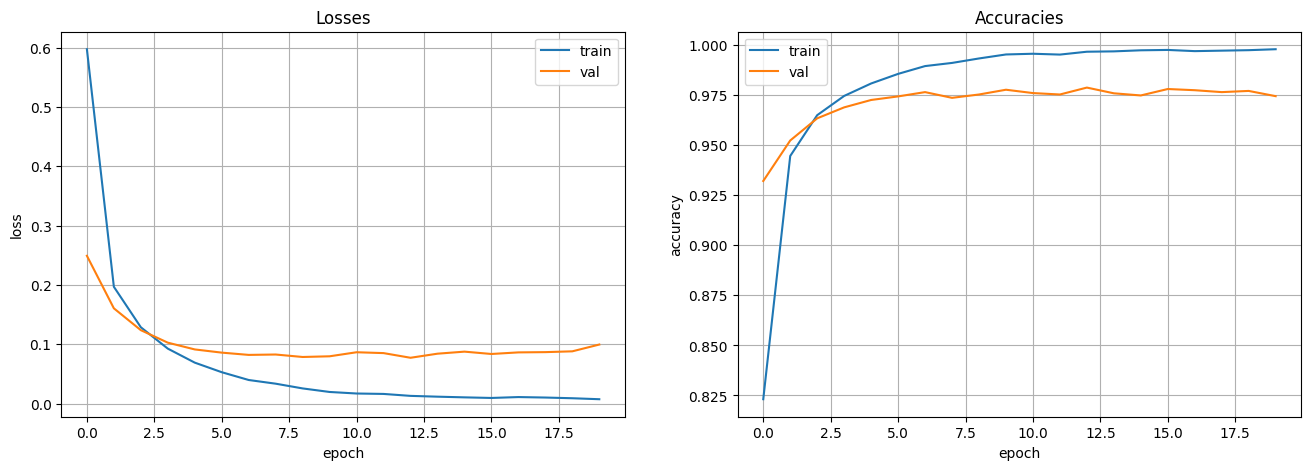

Epoch 19
train_loss 0.007299888780454034 train_accuracy 0.9979761904761905
val_loss 0.0994466893792511 val_accuracy 0.9745238095238096


In [110]:
num_epochs = 20
batch_size = 1024

model = NeuralNetwork(X_train.shape[1], [512, 256, 128], 10) # ~0.5M
trainable_layers = model.get_trainable_layers()
trainable_layers_ids = [str(i) for i in range(len(trainable_layers))]
np.random.seed(42)
optimizer = Adam(learning_rate=0.001, beta1=0.9, beta2=0.99)
criterion = CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print("Epoch", str(epoch))

    new_perm = np.random.permutation(l_train)
    new_X_train = X_train[new_perm]
    new_y_train = y_train[new_perm]
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    for i in tqdm(range(0, l_train, batch_size), desc=f"Epoch {epoch} training"):
        data = new_X_train[i: i + batch_size, :]
        target = new_y_train[i: i + batch_size]
        optimizer.zero_grad(trainable_layers)
        pred = model(data)
        loss = criterion(pred, target)
        grad = criterion.backward()
        grad = model.backward(grad)
        optimizer.update(trainable_layers, trainable_layers_ids)
        train_loss += loss * data.shape[0]
        accuracy = (np.argmax(pred, axis=1) == target).mean()
        train_accuracy += accuracy * data.shape[0]
    train_loss /= l_train
    train_accuracy /= l_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss = 0.0
    val_accuracy = 0.0
    for i in tqdm(range(0, l_val, batch_size), desc=f"Epoch {epoch} validation"):
        data = X_val[i: i + batch_size, :]
        target = y_val[i: i + batch_size]
        pred = model(data)
        loss = criterion(pred, target)
        val_loss += loss * data.shape[0]
        accuracy = (np.argmax(pred, axis=1) == target).mean()
        val_accuracy += accuracy * data.shape[0]
    val_loss /= l_val
    val_accuracy /= l_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    clear_output()
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    ax[0].plot(np.arange(len(train_losses)), train_losses, label='train')
    ax[0].plot(np.arange(len(val_losses)), val_losses, label='val')
    ax[0].set_xlabel('epoch')
    ax[0].set_ylabel('loss')
    ax[0].set_title('Losses')
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(np.arange(len(train_accuracies)), train_accuracies, label='train')
    ax[1].plot(np.arange(len(val_accuracies)), val_accuracies, label='val')
    ax[1].set_xlabel('epoch')
    ax[1].set_ylabel('accuracy')
    ax[1].set_title('Accuracies')
    ax[1].legend()
    ax[1].grid()

    plt.show()

    print("Epoch", str(epoch))
    print("train_loss", str(train_losses[-1]), "train_accuracy", str(train_accuracies[-1]))
    print("val_loss", str(val_losses[-1]), "val_accuracy", str(val_accuracies[-1]))


In [114]:
X_test = pd.read_csv('test.csv').values.astype(np.float32) / 255.0
results = np.zeros((X_test.shape[0], 2), dtype=int)
results[:, 0] = np.arange(1, results.shape[0] + 1, dtype=int)

l_test = X_test.shape[0]

X_test.shape, results.shape

((28000, 784), (28000, 2))

In [115]:
model.eval()
for i in tqdm(range(0, l_test, batch_size), desc=f"Epoch {epoch} testing"):
    data = X_test[i: i + batch_size, :]
    pred = model(data)
    results[i: i + batch_size, 1] = np.argmax(pred, axis=1)

Epoch 19 testing: 100%|██████████| 28/28 [00:01<00:00, 20.55it/s]


In [116]:
df = pd.DataFrame(data={"ImageId": results[:, 0], "Label" : results[:, 1]})
df.to_csv("submission.csv", index=False)